# Multiple Modulation Indexes With AWGN Channel

Let the ideal deterministic input be one isolated rectangular pulse centered in a finite observation interval of length $T$:
$$
p(t)=\operatorname{rect}\!\left(\frac{t-T/2}{\tau}\right),
$$
where $\tau$ is the pulse width. This is one pulse, not a rectangular pulse train.

To avoid using a perfect discontinuous rectangle, the actual input signal in the notebook is a truncated Fourier approximation over the interval $[0,T]$. With duty factor $D=\tau/T$, the centered rectangular pulse has Fourier-series coefficients proportional to
$$
D\operatorname{sinc}(kD), \qquad \operatorname{sinc}(u)=\frac{\sin(\pi u)}{\pi u}.
$$
Let the retained Fourier indexes be an arbitrary finite set of positive integer bins
$$
\mathcal{K}=\{k_1,k_2,\ldots,k_M\}.
$$
The approximation is then
$$
x(t)=D+2\sum_{k\in\mathcal{K}}D\operatorname{sinc}(kD)\cos\!\left(2\pi k\frac{t-T/2}{T}\right).
$$
The retained set $\mathcal{K}$ is arbitrary: it may contain odd indexes, even indexes, consecutive indexes, or any other selected positive Fourier bins.

This is a band-limited approximation to one $\operatorname{rect}(\cdot)$ pulse, so the edges are rounded and Gibbs oscillations may appear. The normalized modulation message is
$$
m(t)=\frac{x(t)-\overline{x}}{\max_t |x(t)-\overline{x}|}, \qquad |m(t)|\le 1.
$$

The carrier is
$$
c(t)=A_c\cos(2\pi f_c t),
$$
and the transmitted AM waveform for modulation index $\mu$ is
$$
s_\mu(t)=A_c\bigl[1+\mu m(t)\bigr]\cos(2\pi f_c t).
$$

For the family $\mu\in\{0.78,1,1.2\}$, the first plots show increasing modulation depth on this particular retained-bin message. The general AM thresholds are still useful: for a fully bipolar message with $\min m(t)=-1$, $\mu=1$ is critical and $\mu>1$ is over-modulated. In the actual retained-bin approximation used here, however, $m(t)$ does not reach $-1$, so all three initial envelopes remain positive. The explicit over-modulation stress test later uses a bipolar-normalized version of the same waveform so that envelope sign reversal really occurs.

For the ideal rectangular pulse of width $\tau$, the continuous sinc spectral envelope has its first null at
$$
B_{\text{base}}=\frac{1}{\tau}.
$$
The finite interval $T$ sets the Fourier-bin spacing used by the approximation:
$$
\Delta f=\frac{1}{T}.
$$
If the largest retained index is
$$
k_{\max}=\max_{k\in\mathcal{K}}k,
$$
then the approximation itself only contains deterministic baseband bins up to
$$
B_{\text{approx}}=\frac{k_{\max}}{T}.
$$
For conventional AM, the first-null bandwidth associated with the ideal pulse remains
$$
B_{\text{AM}}=2B_{\text{base}}=\frac{2}{\tau},
$$
while the truncated approximation occupies retained sidebands around $f_c$ at $f_c\pm k/T$ for every $k\in\mathcal{K}$.

The transmission channel is modeled as additive white Gaussian noise (AWGN):
$$
y_\mu(t)=s_\mu(t)+n(t), \qquad n(t)\sim\mathcal{N}(0,1).
$$
The transmitted signals $s_\mu(t)$ are deterministic once $x(t)$ is fixed, while the received signals $y_\mu(t)$ are stochastic because they include AWGN.


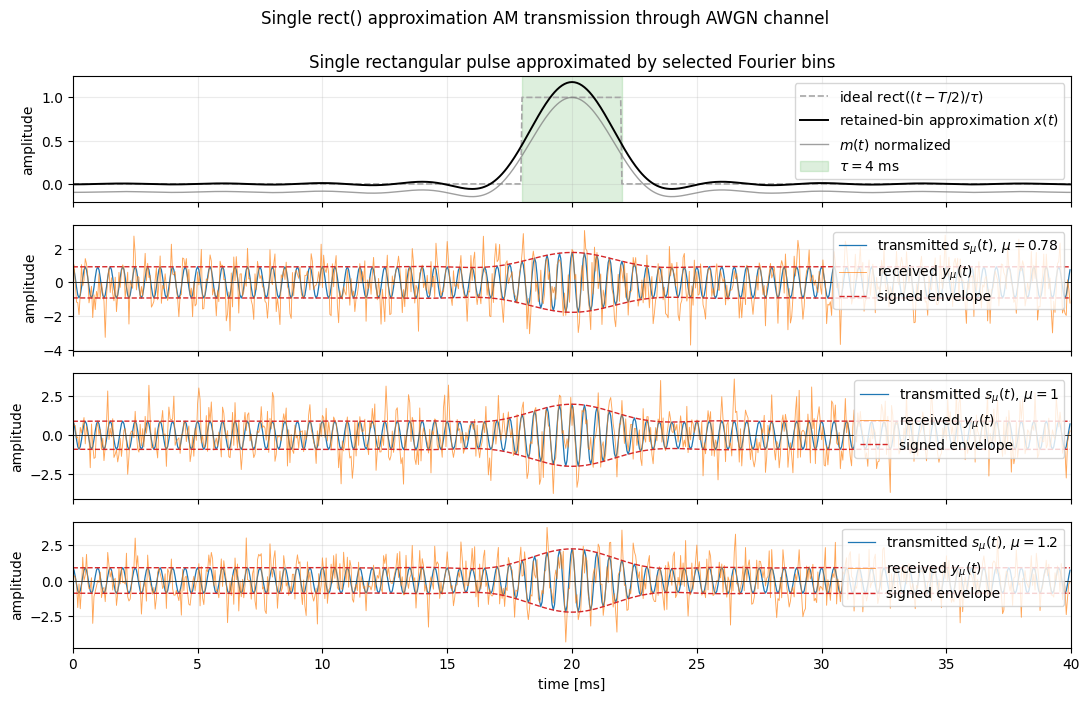

T = 0.0400 s, tau = 0.0040 s, duty cycle = 0.100
Fourier bin spacing Delta f = 1/T = 25.0 Hz
Retained bins = [1, 2, 3, 4, 5, 6, 7, 8, 9], highest retained baseband bin = 225.0 Hz
Ideal rect first-null bandwidth B_base = 1/tau = 250.0 Hz
Ideal AM first-null occupied bandwidth B_AM = 2/tau = 500.0 Hz


In [22]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# Time, carrier, rectangular pulse approximation, and channel parameters.
fs = 20_000
T = 40e-3       # finite observation interval / Fourier-series period [s]
tau = 4e-3     # width of the single ideal rect() pulse [s]
duration = T
t = np.arange(0, duration, 1 / fs)
fc = 2_000
Ac = 1.0
noise_variance = 1.0
frequency_axis_max = 3_000
mus = [0.78, 1.0, 1.2]

# Retained positive Fourier indexes. Edit this array freely; bins need not be odd.
bins = np.arange(1, 10, dtype=int)
if bins.size == 0 or np.any(bins <= 0) or len(np.unique(bins)) != bins.size:
    raise ValueError("bins must contain unique positive integer indexes")

max_bin = int(np.max(bins))
duty_cycle = tau / T
delta_f = 1 / T
baseband_bandwidth = 1 / tau
approx_bandwidth = max_bin / T
am_bandwidth = 2 * baseband_bandwidth
approx_am_bandwidth = 2 * approx_bandwidth

# One ideal pulse is used only as a visual reference. The modulating signal uses
# the truncated Fourier approximation specified by the editable bins array.
t_center = T / 2
ideal_rect = (np.abs(t - t_center) <= tau / 2).astype(float)

x = duty_cycle * np.ones_like(t)
for k in bins:
    coefficient = duty_cycle * np.sinc(k * duty_cycle)
    x += 2 * coefficient * np.cos(2 * np.pi * k * (t - t_center) / T)

x_centered = x - np.mean(x)
m = x_centered / np.max(np.abs(x_centered))
carrier = np.cos(2 * np.pi * fc * t)

transmitted = {}
received = {}
for mu in mus:
    envelope = Ac * (1 + mu * m)
    s = envelope * carrier
    n = rng.normal(loc=0.0, scale=np.sqrt(noise_variance), size=t.size)
    y = s + n
    transmitted[mu] = s
    received[mu] = y

fig, axes = plt.subplots(len(mus) + 1, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t * 1_000, ideal_rect, color="0.65", linestyle="--", linewidth=1.2, label=r"ideal $\operatorname{rect}((t-T/2)/\tau)$")
axes[0].plot(t * 1_000, x, color="black", linewidth=1.4, label=r"retained-bin approximation $x(t)$")
axes[0].plot(t * 1_000, m, color="tab:gray", linewidth=1.0, alpha=0.75, label="$m(t)$ normalized")
axes[0].axvspan((t_center - tau / 2) * 1_000, (t_center + tau / 2) * 1_000, color="tab:green", alpha=0.16, label=rf"$\tau={tau * 1_000:g}$ ms")
axes[0].set_title("Single rectangular pulse approximated by selected Fourier bins")
axes[0].set_ylabel("amplitude")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

for ax, mu in zip(axes[1:], mus):
    envelope = Ac * (1 + mu * m)
    ax.plot(t * 1_000, transmitted[mu], linewidth=0.9, label=rf"transmitted $s_{{\mu}}(t)$, $\mu={mu:g}$")
    ax.plot(t * 1_000, received[mu], color="tab:orange", linewidth=0.65, alpha=0.7, label=rf"received $y_{{\mu}}(t)$")
    ax.plot(t * 1_000, envelope, "--", color="tab:red", linewidth=1.0, label="signed envelope")
    ax.plot(t * 1_000, -envelope, "--", color="tab:red", linewidth=1.0)
    ax.axhline(0, color="0.2", linewidth=0.7)
    ax.set_ylabel("amplitude")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("time [ms]")
axes[-1].set_xlim(0, T * 1_000)
fig.suptitle("Single rect() approximation AM transmission through AWGN channel", y=0.995)
fig.tight_layout()
plt.show()

print(f"T = {T:.4f} s, tau = {tau:.4f} s, duty cycle = {duty_cycle:.3f}")
print(f"Fourier bin spacing Delta f = 1/T = {delta_f:.1f} Hz")
print(f"Retained bins = {bins.tolist()}, highest retained baseband bin = {approx_bandwidth:.1f} Hz")
print(f"Ideal rect first-null bandwidth B_base = 1/tau = {baseband_bandwidth:.1f} Hz")
print(f"Ideal AM first-null occupied bandwidth B_AM = 2/tau = {am_bandwidth:.1f} Hz")


## Spectrum And Bandwidth From $\tau$ And $T$

The signal $x(t)$ is a deterministic approximation to one $\operatorname{rect}((t-T/2)/\tau)$ pulse. Because it is explicitly built from the retained Fourier-index set $\mathcal{K}$, its deterministic spectrum is shown as an analytical stem plot of those known bin coefficients, not as a windowed FFT curve.

The AM transmitted signal contains a carrier at $f_c$ plus sideband stems at $f_c\pm k/T$ for every retained $k\in\mathcal{K}$. The sideband amplitudes are computed from the normalized message $m(t)$, because the transmitter modulates $m(t)$ rather than the unnormalized approximation $x(t)$. The received channel outputs $y_\mu(t)=s_\mu(t)+n(t)$ include AWGN, so they are still plotted as PSD estimates.

The ideal rectangular pulse has first-null bandwidth $B_{\text{base}}=1/\tau$. The finite interval $T$ sets the Fourier-bin spacing, $\Delta f=1/T$. If $k_{\max}=\max_{k\in\mathcal{K}}k$, the approximation contains baseband components up to $B_{\text{approx}}=k_{\max}/T$.

The green regions mark the ideal first-null bandwidth from $\tau$. The purple markers show the highest retained approximation bin. The final plot shows the bandwidth values as horizontal reference lines.


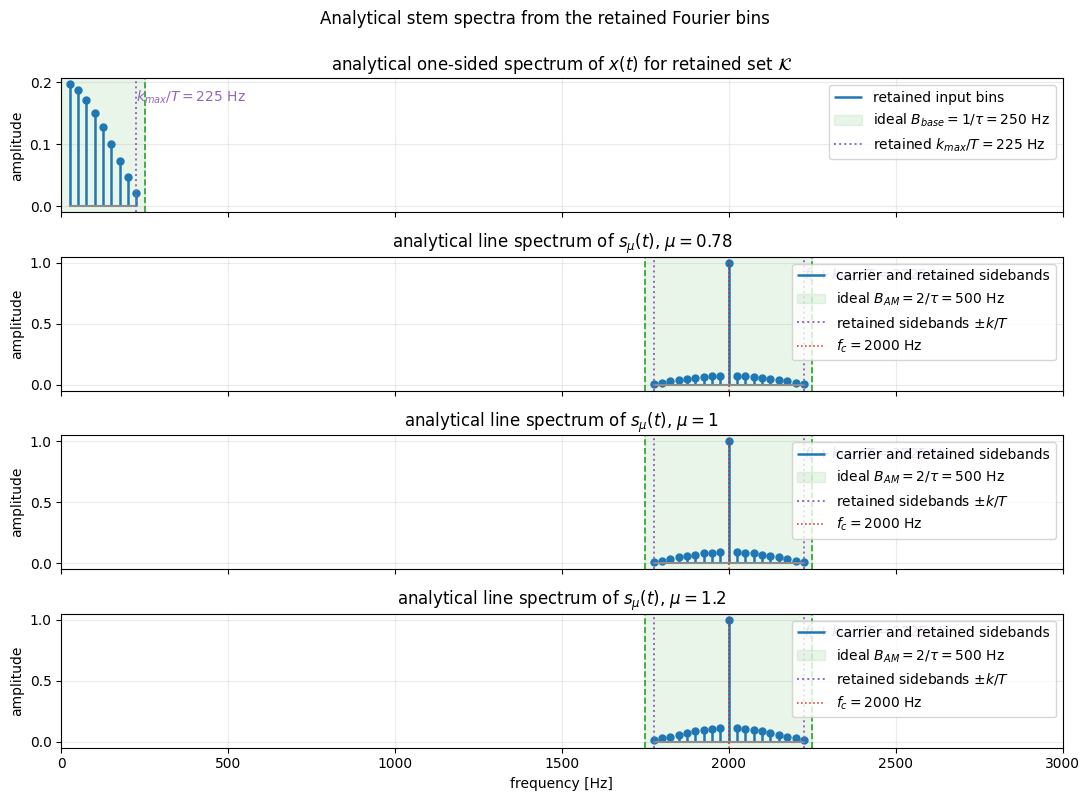

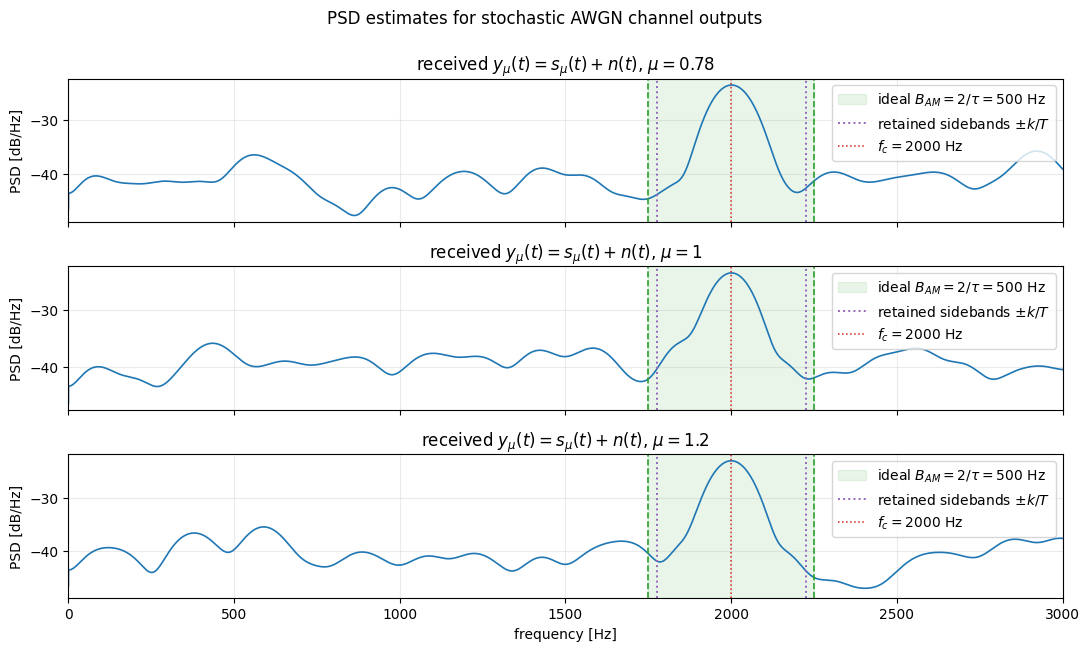

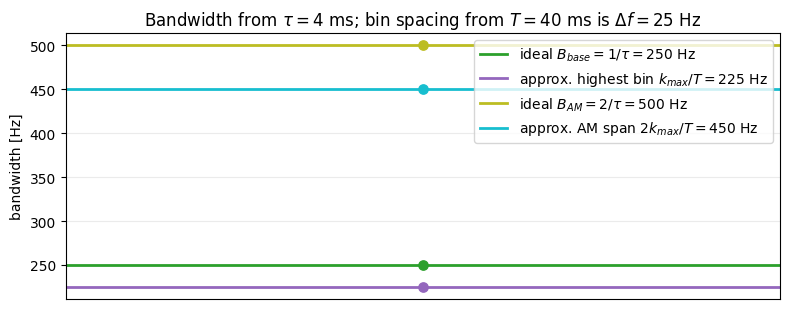

In [23]:
def welch_psd(y, fs, segment_length=256, overlap=0.75, n_fft=131_072):
    """Estimate a one-sided PSD using averaged Hann-window periodograms."""
    y = np.asarray(y, dtype=float)
    step = int(segment_length * (1 - overlap))
    if step <= 0:
        raise ValueError("overlap must be less than 1")
    if y.size < segment_length:
        raise ValueError("signal is shorter than one PSD segment")

    window = np.hanning(segment_length)
    window_power = np.sum(window**2)
    starts = range(0, y.size - segment_length + 1, step)

    spectra = []
    for start in starts:
        segment = y[start:start + segment_length]
        segment = segment - np.mean(segment)
        coeffs = np.fft.rfft(segment * window, n=n_fft)
        psd = (np.abs(coeffs) ** 2) / (fs * window_power)
        if n_fft > 1:
            psd[1:-1] *= 2
        spectra.append(psd)

    freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
    return freqs, np.mean(spectra, axis=0)


def db10(values, floor=1e-18):
    return 10 * np.log10(np.maximum(values, floor))


def stem_spectrum(ax, freqs, amplitudes, *, color, label):
    markerline, stemlines, baseline = ax.stem(freqs, amplitudes, linefmt=color, markerfmt=f"{color}o", basefmt="0.55")
    markerline.set_markersize(5)
    stemlines.set_linewidth(1.8)
    stemlines.set_label(label)
    return markerline, stemlines, baseline


def mark_baseband_bandwidth(ax):
    ax.axvspan(0, baseband_bandwidth, color="tab:green", alpha=0.10, label=rf"ideal $B_{{base}}=1/\tau={baseband_bandwidth:g}$ Hz")
    ax.axvline(baseband_bandwidth, color="tab:green", linestyle="--", linewidth=1.2)
    ax.axvline(approx_bandwidth, color="tab:purple", linestyle=":", linewidth=1.4, label=rf"retained $k_{{max}}/T={approx_bandwidth:g}$ Hz")


def mark_am_bandwidth(ax):
    ideal_lower = fc - baseband_bandwidth
    ideal_upper = fc + baseband_bandwidth
    approx_lower = fc - approx_bandwidth
    approx_upper = fc + approx_bandwidth
    ax.axvspan(ideal_lower, ideal_upper, color="tab:green", alpha=0.10, label=rf"ideal $B_{{AM}}=2/\tau={am_bandwidth:g}$ Hz")
    ax.axvline(ideal_lower, color="tab:green", linestyle="--", linewidth=1.2)
    ax.axvline(ideal_upper, color="tab:green", linestyle="--", linewidth=1.2)
    ax.axvline(approx_lower, color="tab:purple", linestyle=":", linewidth=1.4, label=rf"retained sidebands $\pm k/T$")
    ax.axvline(approx_upper, color="tab:purple", linestyle=":", linewidth=1.4)
    ax.axvline(fc, color="tab:red", linestyle=":", linewidth=1.1, label=rf"$f_c={fc}$ Hz")


bin_freqs = bins / T
# x(t) = D + 2 a_k cos(...), so each positive one-sided cosine amplitude is 2 a_k.
bin_coefficients = duty_cycle * np.sinc(bins * duty_cycle)
one_sided_input_amplitudes = 2 * np.abs(bin_coefficients)
message_normalization = np.max(np.abs(x_centered))
one_sided_message_amplitudes = one_sided_input_amplitudes / message_normalization

fig, axes = plt.subplots(len(mus) + 1, 1, figsize=(11, 8), sharex=True)

stem_spectrum(axes[0], bin_freqs, one_sided_input_amplitudes, color="C0", label="retained input bins")
axes[0].set_title(r"analytical one-sided spectrum of $x(t)$ for retained set $\mathcal{K}$")
axes[0].set_ylabel("amplitude")
axes[0].grid(True, alpha=0.25)
mark_baseband_bandwidth(axes[0])
axes[0].text(approx_bandwidth, axes[0].get_ylim()[1] * 0.92, rf"$k_{{max}}/T={approx_bandwidth:g}$ Hz", color="tab:purple", ha="left", va="top")
axes[0].legend(loc="upper right")

for ax, mu in zip(axes[1:], mus):
    sideband_offsets = bin_freqs
    sideband_amplitudes = mu * one_sided_message_amplitudes / 2
    sideband_freqs = np.concatenate([fc - sideband_offsets[::-1], [fc], fc + sideband_offsets])
    amplitudes = np.concatenate([sideband_amplitudes[::-1], [Ac], sideband_amplitudes])
    stem_spectrum(ax, sideband_freqs, amplitudes, color="C0", label="carrier and retained sidebands")
    ax.set_title(rf"analytical line spectrum of $s_{{\mu}}(t)$, $\mu={mu:g}$")
    ax.set_ylabel("amplitude")
    ax.grid(True, alpha=0.25)
    mark_am_bandwidth(ax)
    ax.text(fc + approx_bandwidth, ax.get_ylim()[1] * 0.92, rf"$f_c+k_{{max}}/T={fc + approx_bandwidth:g}$ Hz", color="tab:purple", ha="left", va="top")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("frequency [Hz]")
axes[-1].set_xlim(0, frequency_axis_max)
fig.suptitle("Analytical stem spectra from the retained Fourier bins", y=0.995)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(len(mus), 1, figsize=(11, 6.5), sharex=True)

for ax, mu in zip(axes, mus):
    freqs, psd = welch_psd(received[mu], fs, segment_length=256, overlap=0.75, n_fft=131_072)
    ax.plot(freqs, db10(psd), linewidth=1.2)
    ax.set_title(rf"received $y_{{\mu}}(t)=s_{{\mu}}(t)+n(t)$, $\mu={mu:g}$")
    ax.set_ylabel("PSD [dB/Hz]")
    mark_am_bandwidth(ax)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("frequency [Hz]")
axes[-1].set_xlim(0, frequency_axis_max)
fig.suptitle("PSD estimates for stochastic AWGN channel outputs", y=0.995)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.axhline(baseband_bandwidth, color="tab:green", linewidth=2.0, label=rf"ideal $B_{{base}}=1/\tau={baseband_bandwidth:g}$ Hz")
ax.axhline(approx_bandwidth, color="tab:purple", linewidth=2.0, label=rf"approx. highest bin $k_{{max}}/T={approx_bandwidth:g}$ Hz")
ax.axhline(am_bandwidth, color="tab:olive", linewidth=2.0, label=rf"ideal $B_{{AM}}=2/\tau={am_bandwidth:g}$ Hz")
ax.axhline(approx_am_bandwidth, color="tab:cyan", linewidth=2.0, label=rf"approx. AM span $2k_{{max}}/T={approx_am_bandwidth:g}$ Hz")
ax.scatter([0.5], [baseband_bandwidth], color="tab:green", s=45)
ax.scatter([0.5], [approx_bandwidth], color="tab:purple", s=45)
ax.scatter([0.5], [am_bandwidth], color="tab:olive", s=45)
ax.scatter([0.5], [approx_am_bandwidth], color="tab:cyan", s=45)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_ylabel("bandwidth [Hz]")
ax.set_title(rf"Bandwidth from $\tau={tau * 1_000:g}$ ms; bin spacing from $T={T * 1_000:g}$ ms is $\Delta f={delta_f:g}$ Hz")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


## Demodulation Methods

This section compares three AM demodulation methods against the original normalized message $m(t)$. The overlays use the clean transmitted waveform $s_\mu(t)$ rather than the noisy channel output $y_\mu(t)$, so the plot shows the effect of each demodulator configuration directly. The AWGN channel remains defined in the previous cells.

The comparison is shown for the under-modulated case $\mu=0.78$, because a conventional envelope detector assumes the AM envelope remains nonnegative.

### 1. Envelope detector with good and bad inertia

An envelope detector rectifies the AM waveform and follows its envelope with an inertial smoothing stage. A good detector should attack quickly enough to catch peaks but release slowly enough to reject carrier ripple:
$$
e[n]=\alpha e[n-1]+(1-\alpha)|s[n]|.
$$
The plot compares:

- good inertia: fast attack and moderate release;
- bad inertia: excessive smoothing, which cannot follow the message shape.

After envelope recovery, the normalized message estimate is
$$
\widehat{m}_{\text{env}}(t)=\frac{e(t)/A_c-1}{\mu}.
$$

### 2. Coherent demodulation with $\phi=0$ and $\phi\ne0$

Coherent demodulation multiplies the AM signal by a local carrier:
$$
2s(t)\cos(2\pi f_c t+\phi).
$$
After low-pass filtering, the ideal synchronized case $\phi=0$ recovers $A_c[1+\mu m(t)]$. A nonzero phase error attenuates and biases the recovered message if it is not corrected.

### 3. I/Q demodulation: balanced vs imbalanced

Balanced I/Q demodulation mixes with orthogonal cosine and sine local oscillators and forms a complex baseband signal. For AM, the magnitude of the balanced complex baseband gives the modulation envelope. Gain mismatch and quadrature phase error produce an imbalanced recovery, which is overlaid against the balanced case.


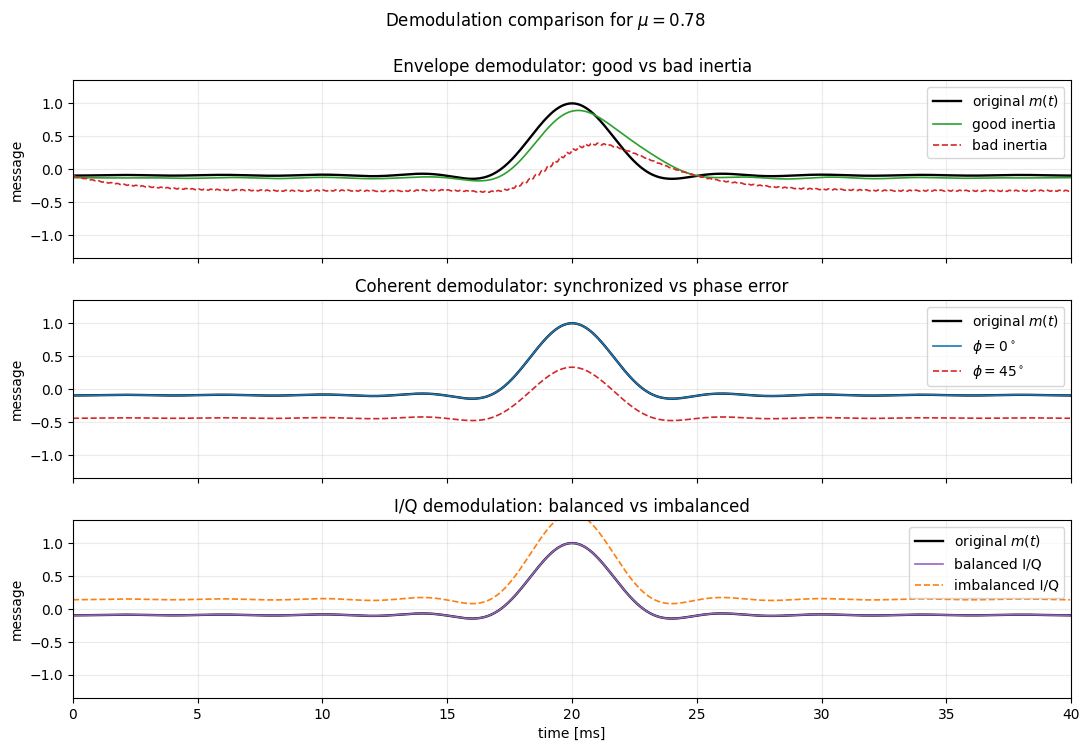

Demodulation example uses clean s_mu(t) with mu = 0.78
Low-pass cutoff = 303.8 Hz
Envelope good attack/release = 0.060 ms / 3.000 ms
Envelope bad attack/release = 0.900 ms / 4.192 ms
Coherent phase cases = 0.0 deg and 45.0 deg
I/Q imbalance: I gain = 1.18, Q gain = 0.58, phase error = 22.0 deg


In [24]:
def lowpass_fft(signal, fs, cutoff_hz):
    """Ideal zero-phase low-pass filter for demonstration-only demodulation."""
    signal = np.asarray(signal, dtype=float)
    freqs = np.fft.rfftfreq(signal.size, d=1 / fs)
    coeffs = np.fft.rfft(signal)
    coeffs[freqs > cutoff_hz] = 0
    return np.fft.irfft(coeffs, n=signal.size)


def envelope_detector(signal, fs, attack_tau, release_tau):
    """Peak-following envelope detector with separate attack and release inertia."""
    rectified = np.abs(signal)
    envelope = np.empty_like(rectified)
    envelope[0] = rectified[0]

    alpha_attack = np.exp(-1 / (fs * attack_tau))
    alpha_release = np.exp(-1 / (fs * release_tau))

    for n in range(1, rectified.size):
        alpha = alpha_attack if rectified[n] > envelope[n - 1] else alpha_release
        envelope[n] = alpha * envelope[n - 1] + (1 - alpha) * rectified[n]

    return envelope


def recover_message_from_envelope(envelope, Ac, mu):
    """Map a recovered AM envelope A_c(1 + mu m) back to m."""
    return (envelope / Ac - 1) / mu


def coherent_demodulate(signal, fs, fc, Ac, mu, phi, cutoff_hz):
    mixed = 2 * signal * np.cos(2 * np.pi * fc * t + phi)
    baseband = lowpass_fft(mixed, fs, cutoff_hz=cutoff_hz)
    return recover_message_from_envelope(baseband, Ac, mu)


def iq_demodulate(signal, fs, fc, Ac, mu, cutoff_hz, i_gain=1.0, q_gain=1.0, phase_error=0.0):
    i_branch = lowpass_fft(2 * i_gain * signal * np.cos(2 * np.pi * fc * t), fs, cutoff_hz=cutoff_hz)
    q_branch = lowpass_fft(-2 * q_gain * signal * np.sin(2 * np.pi * fc * t + phase_error), fs, cutoff_hz=cutoff_hz)
    complex_baseband = i_branch + 1j * q_branch
    envelope = np.abs(complex_baseband)
    return recover_message_from_envelope(envelope, Ac, mu)


mu_demod = 0.78
s_demod = transmitted[mu_demod]

# The cutoff keeps the retained baseband bins and adds modest transition margin.
lp_cutoff = 1.35 * approx_bandwidth

# Envelope detector: good inertia versus intentionally bad inertia.
# Good release must be several carrier periods, but still shorter than the
# message-scale variations. A post-LPF removes the remaining carrier ripple.
good_attack_tau = 0.12 / fc
good_release_tau = 6.0 / fc
bad_attack_tau = 1.8 / fc
bad_release_tau = 8 / (2 * np.pi * lp_cutoff)

env_good = envelope_detector(s_demod, fs, attack_tau=good_attack_tau, release_tau=good_release_tau)
env_bad = envelope_detector(s_demod, fs, attack_tau=bad_attack_tau, release_tau=bad_release_tau)
env_good = lowpass_fft(env_good, fs, cutoff_hz=lp_cutoff)
m_env_good = recover_message_from_envelope(env_good, Ac, mu_demod)
m_env_bad = recover_message_from_envelope(env_bad, Ac, mu_demod)

# Coherent demodulator: synchronized carrier versus carrier phase error.
phi_good = 0.0
phi_bad = np.deg2rad(45)
m_coherent_good = coherent_demodulate(s_demod, fs, fc, Ac, mu_demod, phi_good, lp_cutoff)
m_coherent_bad = coherent_demodulate(s_demod, fs, fc, Ac, mu_demod, phi_bad, lp_cutoff)

# I/Q demodulator: balanced versus deliberately imbalanced.
i_gain_bad = 1.18
q_gain_bad = 0.58
quadrature_phase_error = np.deg2rad(22)
m_iq_balanced = iq_demodulate(s_demod, fs, fc, Ac, mu_demod, lp_cutoff)
m_iq_imbalanced = iq_demodulate(
    s_demod,
    fs,
    fc,
    Ac,
    mu_demod,
    lp_cutoff,
    i_gain=i_gain_bad,
    q_gain=q_gain_bad,
    phase_error=quadrature_phase_error,
)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
time_ms = t * 1_000

axes[0].plot(time_ms, m, color="black", linewidth=1.7, label="original $m(t)$")
axes[0].plot(time_ms, m_env_good, color="tab:green", linewidth=1.2, label="good inertia")
axes[0].plot(time_ms, m_env_bad, color="tab:red", linewidth=1.2, linestyle="--", label="bad inertia")
axes[0].set_title("Envelope demodulator: good vs bad inertia")
axes[0].set_ylabel("message")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

axes[1].plot(time_ms, m, color="black", linewidth=1.7, label="original $m(t)$")
axes[1].plot(time_ms, m_coherent_good, color="tab:blue", linewidth=1.2, label=rf"$\phi={np.rad2deg(phi_good):.0f}^\circ$")
axes[1].plot(time_ms, m_coherent_bad, color="tab:red", linewidth=1.2, linestyle="--", label=rf"$\phi={np.rad2deg(phi_bad):.0f}^\circ$")
axes[1].set_title(r"Coherent demodulator: synchronized vs phase error")
axes[1].set_ylabel("message")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

axes[2].plot(time_ms, m, color="black", linewidth=1.7, label="original $m(t)$")
axes[2].plot(time_ms, m_iq_balanced, color="tab:purple", linewidth=1.2, label="balanced I/Q")
axes[2].plot(time_ms, m_iq_imbalanced, color="tab:orange", linewidth=1.2, linestyle="--", label="imbalanced I/Q")
axes[2].set_title("I/Q demodulation: balanced vs imbalanced")
axes[2].set_xlabel("time [ms]")
axes[2].set_ylabel("message")
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right")

for ax in axes:
    ax.set_ylim(-1.35, 1.35)
axes[-1].set_xlim(0, T * 1_000)
fig.suptitle(rf"Demodulation comparison for $\mu={mu_demod:g}$", y=0.995)
fig.tight_layout()
plt.show()

print(f"Demodulation example uses clean s_mu(t) with mu = {mu_demod}")
print(f"Low-pass cutoff = {lp_cutoff:.1f} Hz")
print(f"Envelope good attack/release = {good_attack_tau * 1_000:.3f} ms / {good_release_tau * 1_000:.3f} ms")
print(f"Envelope bad attack/release = {bad_attack_tau * 1_000:.3f} ms / {bad_release_tau * 1_000:.3f} ms")
print(f"Coherent phase cases = {np.rad2deg(phi_good):.1f} deg and {np.rad2deg(phi_bad):.1f} deg")
print(f"I/Q imbalance: I gain = {i_gain_bad:.2f}, Q gain = {q_gain_bad:.2f}, phase error = {np.rad2deg(quadrature_phase_error):.1f} deg")


## Bandwidth After Demodulation

A correct demodulator should recover a baseband signal with the same retained bandwidth as the original message. In this notebook the original approximation uses the retained Fourier-index set $\mathcal{K}$, so the expected recovered baseband bandwidth is
$$
B_{\text{demod}}=B_{\text{approx}}=\frac{k_{\max}}{T}.
$$

The code below measures the recovered bandwidth from each demodulated waveform by projecting it onto the same Fourier-bin grid $k/T$. A bin is counted as present when its normalized amplitude is above a small threshold. If demodulation is successful, the highest detected bin should be $k_{\max}$, and the measured bandwidth should match $B_{\text{approx}}$.


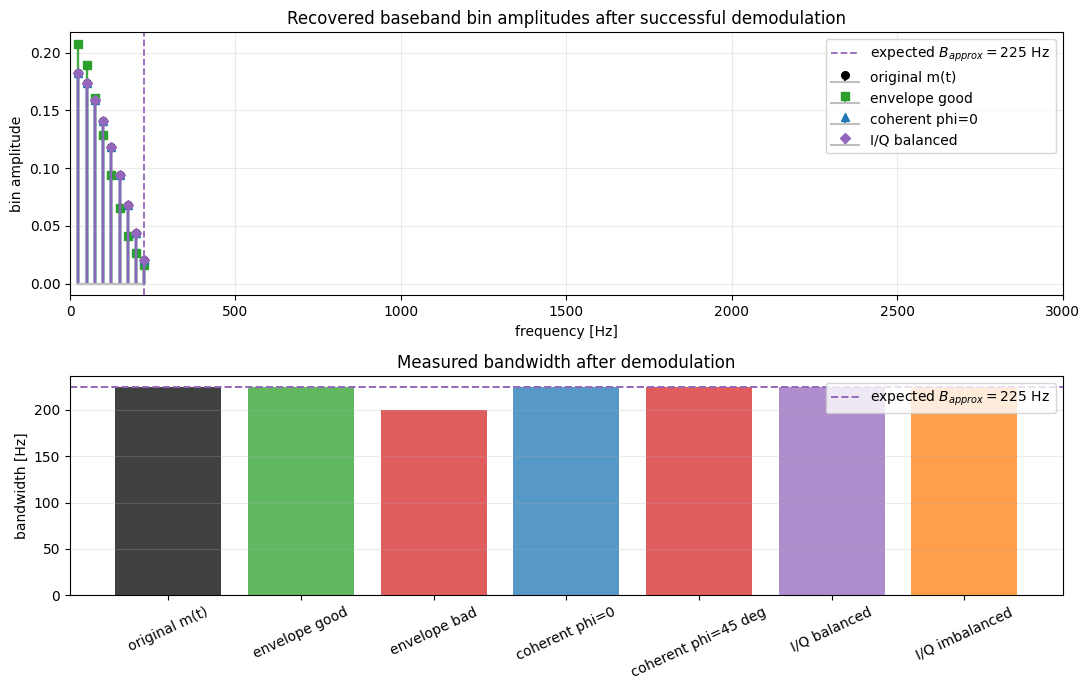

Expected retained baseband bandwidth B_approx = 225.0 Hz
original m(t): measured bandwidth = 225.0 Hz, highest detected bin = 9
envelope good: measured bandwidth = 225.0 Hz, highest detected bin = 9
envelope bad: measured bandwidth = 200.0 Hz, highest detected bin = 8
coherent phi=0: measured bandwidth = 225.0 Hz, highest detected bin = 9
coherent phi=45 deg: measured bandwidth = 225.0 Hz, highest detected bin = 9
I/Q balanced: measured bandwidth = 225.0 Hz, highest detected bin = 9
I/Q imbalanced: measured bandwidth = 225.0 Hz, highest detected bin = 9


In [25]:
def retained_bin_amplitudes(signal, bins, T):
    """Project signal onto cos/sin Fourier bins and return one-sided amplitudes."""
    centered = np.asarray(signal, dtype=float) - np.mean(signal)
    amplitudes = []
    for k in bins:
        cos_basis = np.cos(2 * np.pi * k * (t - t_center) / T)
        sin_basis = np.sin(2 * np.pi * k * (t - t_center) / T)
        cos_coeff = 2 * np.mean(centered * cos_basis)
        sin_coeff = 2 * np.mean(centered * sin_basis)
        amplitudes.append(np.hypot(cos_coeff, sin_coeff))
    return np.asarray(amplitudes)


def measured_bandwidth_from_bins(signal, bins, T, relative_threshold=0.05):
    amplitudes = retained_bin_amplitudes(signal, bins, T)
    if np.max(amplitudes) <= 0:
        return 0.0, None, amplitudes
    active = amplitudes >= relative_threshold * np.max(amplitudes)
    if not np.any(active):
        return 0.0, None, amplitudes
    highest_bin = int(np.max(bins[active]))
    return highest_bin / T, highest_bin, amplitudes


recovered_signals = {
    "original m(t)": m,
    "envelope good": m_env_good,
    "envelope bad": m_env_bad,
    "coherent phi=0": m_coherent_good,
    "coherent phi=45 deg": m_coherent_bad,
    "I/Q balanced": m_iq_balanced,
    "I/Q imbalanced": m_iq_imbalanced,
}

bandwidth_results = {}
for label, signal in recovered_signals.items():
    measured_bw, highest_bin, amplitudes = measured_bandwidth_from_bins(signal, bins, T)
    bandwidth_results[label] = {
        "bandwidth": measured_bw,
        "highest_bin": highest_bin,
        "amplitudes": amplitudes,
    }

fig, axes = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [1.2, 1.0]})

bin_freqs = bins / T
stem_series = [
    ("original m(t)", "black", "o"),
    ("envelope good", "tab:green", "s"),
    ("coherent phi=0", "tab:blue", "^"),
    ("I/Q balanced", "tab:purple", "D"),
]

for label, color, marker in stem_series:
    result = bandwidth_results[label]
    markerline, stemlines, baseline = axes[0].stem(
        bin_freqs,
        result["amplitudes"],
        linefmt=color,
        markerfmt=marker,
        basefmt="0.75",
        label=label,
    )
    markerline.set_color(color)
    markerline.set_markerfacecolor(color)
    markerline.set_markersize(5.5)
    stemlines.set_color(color)
    stemlines.set_linewidth(1.7)
    stemlines.set_alpha(0.9)

axes[0].axvline(approx_bandwidth, color="tab:purple", linestyle="--", linewidth=1.3, label=rf"expected $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[0].set_title("Recovered baseband bin amplitudes after successful demodulation")
axes[0].set_xlabel("frequency [Hz]")
axes[0].set_ylabel("bin amplitude")
axes[0].set_xlim(0, frequency_axis_max)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

labels = list(bandwidth_results.keys())
values = [bandwidth_results[label]["bandwidth"] for label in labels]
colors = ["black", "tab:green", "tab:red", "tab:blue", "tab:red", "tab:purple", "tab:orange"]
axes[1].bar(labels, values, color=colors, alpha=0.75)
axes[1].axhline(approx_bandwidth, color="tab:purple", linestyle="--", linewidth=1.4, label=rf"expected $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[1].set_title("Measured bandwidth after demodulation")
axes[1].set_ylabel("bandwidth [Hz]")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

print(f"Expected retained baseband bandwidth B_approx = {approx_bandwidth:.1f} Hz")
for label, result in bandwidth_results.items():
    highest = result["highest_bin"] if result["highest_bin"] is not None else "none"
    print(f"{label}: measured bandwidth = {result['bandwidth']:.1f} Hz, highest detected bin = {highest}")


## AWGN Before Modulation

The previous channel model adds noise after modulation:
$$
y_\mu(t)=s_\mu(t)+n(t).
$$
Now consider a different placement: AWGN corrupts the baseband input before modulation. Let
$$
x_n(t)=x(t)+w(t), \qquad w(t)\sim\mathcal{N}(0,\sigma_x^2).
$$
After normalization, the noisy baseband message is
$$
m_n(t)=\frac{x_n(t)-\overline{x_n}}{\max_t |x_n(t)-\overline{x_n}|}.
$$
The AM transmitter then modulates $m_n(t)$:
$$
s_{\mu,n}(t)=A_c\bigl[1+\mu m_n(t)\bigr]\cos(2\pi f_c t).
$$

This is not equivalent to adding AWGN after modulation. Noise before modulation is copied into the AM sidebands and changes the baseband spectrum before the carrier shift. In the spectra below, the clean retained-bin stems are compared against the noisy-input PSD, which shows energy leaking beyond the originally retained bin set.


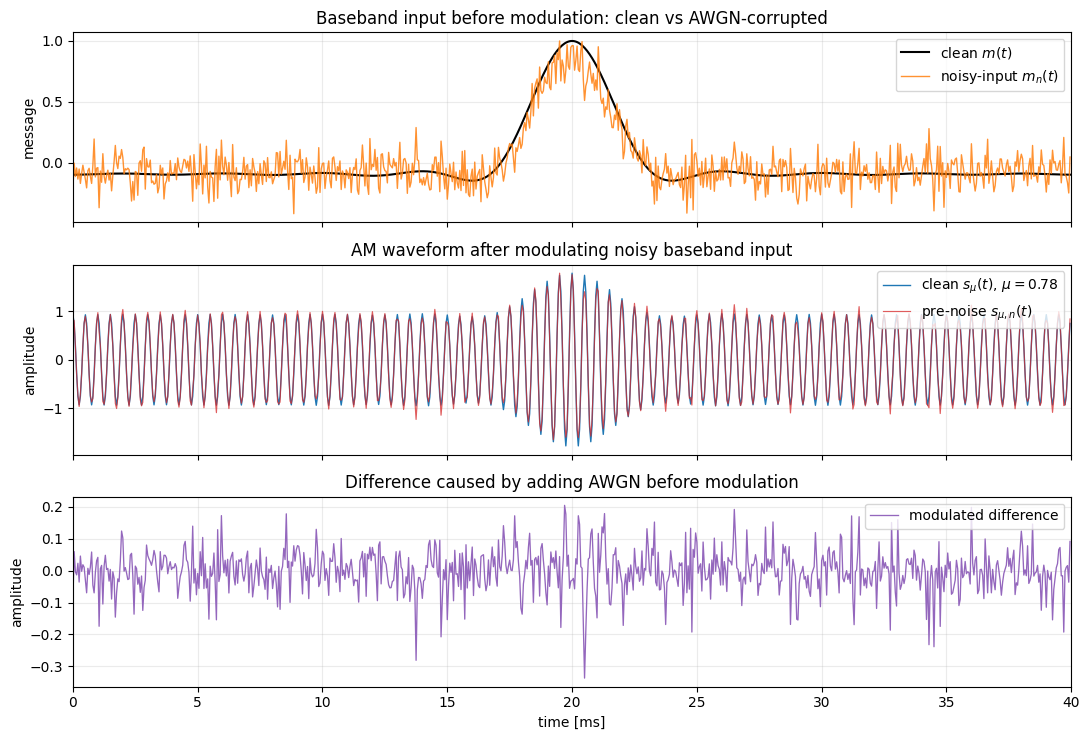

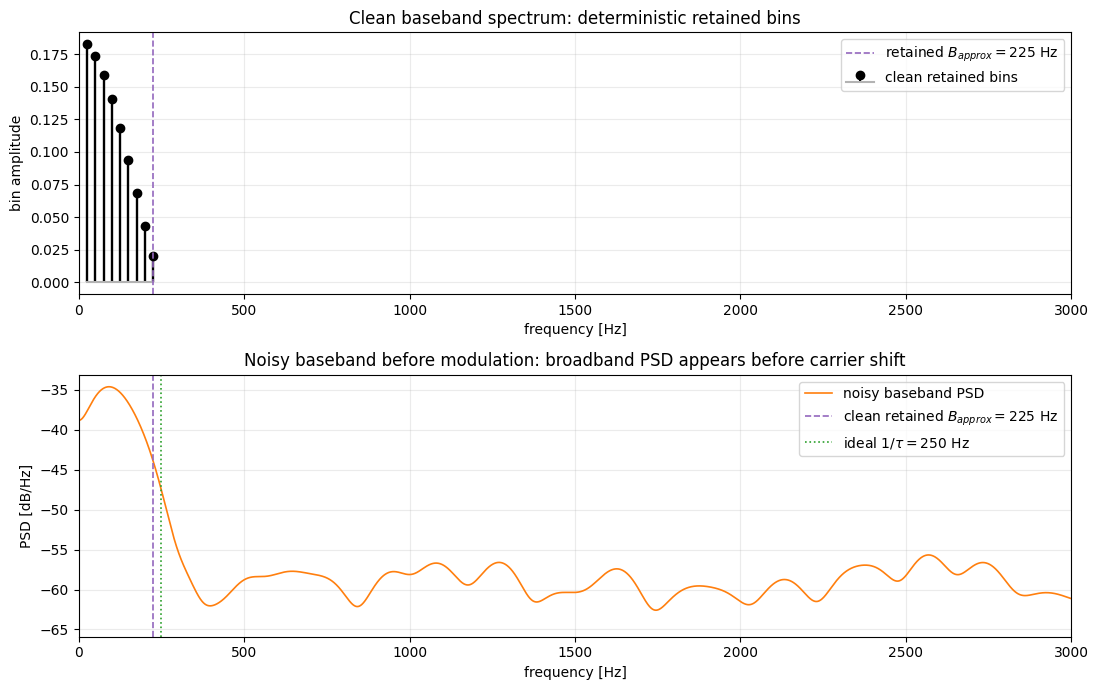

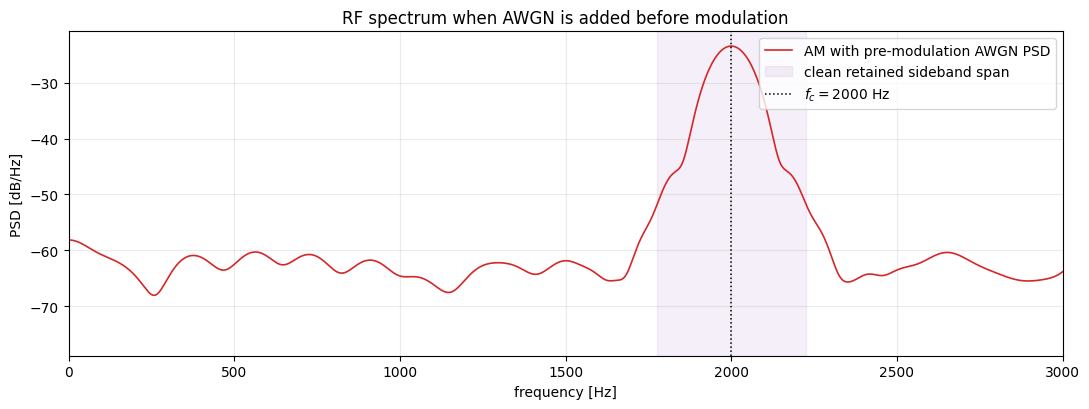

Pre-modulation AWGN variance = 0.020
Modulation index used = 0.78
Noise before modulation broadens the baseband spectrum before it is shifted around the carrier.


In [26]:
input_noise_variance = 0.02
mu_pre_noise = 0.78

w = rng.normal(loc=0.0, scale=np.sqrt(input_noise_variance), size=t.size)
x_noisy = x + w
x_noisy_centered = x_noisy - np.mean(x_noisy)
m_noisy = x_noisy_centered / np.max(np.abs(x_noisy_centered))

s_clean = transmitted[mu_pre_noise]
s_pre_noisy = Ac * (1 + mu_pre_noise * m_noisy) * carrier

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
time_ms = t * 1_000

axes[0].plot(time_ms, m, color="black", linewidth=1.5, label="clean $m(t)$")
axes[0].plot(time_ms, m_noisy, color="tab:orange", linewidth=1.0, alpha=0.85, label="noisy-input $m_n(t)$")
axes[0].set_title("Baseband input before modulation: clean vs AWGN-corrupted")
axes[0].set_ylabel("message")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

axes[1].plot(time_ms, s_clean, color="tab:blue", linewidth=1.0, label=rf"clean $s_{{\mu}}(t)$, $\mu={mu_pre_noise:g}$")
axes[1].plot(time_ms, s_pre_noisy, color="tab:red", linewidth=0.85, alpha=0.75, label=rf"pre-noise $s_{{\mu,n}}(t)$")
axes[1].set_title("AM waveform after modulating noisy baseband input")
axes[1].set_ylabel("amplitude")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

axes[2].plot(time_ms, s_pre_noisy - s_clean, color="tab:purple", linewidth=0.95, label="modulated difference")
axes[2].set_title("Difference caused by adding AWGN before modulation")
axes[2].set_xlabel("time [ms]")
axes[2].set_ylabel("amplitude")
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right")

axes[-1].set_xlim(0, T * 1_000)
fig.tight_layout()
plt.show()

# Frequency-domain comparison: clean deterministic retained bins vs noisy-input PSD.
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

clean_bin_freqs = bins / T
clean_bin_amplitudes = retained_bin_amplitudes(m, bins, T)
markerline, stemlines, baseline = axes[0].stem(clean_bin_freqs, clean_bin_amplitudes, linefmt="black", markerfmt="ko", basefmt="0.7", label="clean retained bins")
stemlines.set_linewidth(1.7)
axes[0].axvline(approx_bandwidth, color="tab:purple", linestyle="--", linewidth=1.2, label=rf"retained $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[0].set_title("Clean baseband spectrum: deterministic retained bins")
axes[0].set_xlabel("frequency [Hz]")
axes[0].set_ylabel("bin amplitude")
axes[0].set_xlim(0, frequency_axis_max)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

freqs_noisy_baseband, psd_noisy_baseband = welch_psd(m_noisy, fs, segment_length=256, overlap=0.75, n_fft=131_072)
freqs_pre_noisy, psd_pre_noisy = welch_psd(s_pre_noisy, fs, segment_length=256, overlap=0.75, n_fft=131_072)

axes[1].plot(freqs_noisy_baseband, db10(psd_noisy_baseband), color="tab:orange", linewidth=1.2, label="noisy baseband PSD")
axes[1].axvline(approx_bandwidth, color="tab:purple", linestyle="--", linewidth=1.2, label=rf"clean retained $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[1].axvline(baseband_bandwidth, color="tab:green", linestyle=":", linewidth=1.2, label=rf"ideal $1/\tau={baseband_bandwidth:g}$ Hz")
axes[1].set_title("Noisy baseband before modulation: broadband PSD appears before carrier shift")
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel("PSD [dB/Hz]")
axes[1].set_xlim(0, frequency_axis_max)
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(freqs_pre_noisy, db10(psd_pre_noisy), color="tab:red", linewidth=1.2, label="AM with pre-modulation AWGN PSD")
ax.axvspan(fc - approx_bandwidth, fc + approx_bandwidth, color="tab:purple", alpha=0.10, label="clean retained sideband span")
ax.axvline(fc, color="black", linestyle=":", linewidth=1.1, label=rf"$f_c={fc}$ Hz")
ax.set_title("RF spectrum when AWGN is added before modulation")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("PSD [dB/Hz]")
ax.set_xlim(0, frequency_axis_max)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print(f"Pre-modulation AWGN variance = {input_noise_variance:.3f}")
print(f"Modulation index used = {mu_pre_noise}")
print("Noise before modulation broadens the baseband spectrum before it is shifted around the carrier.")


## Demodulation And Bandwidth With AWGN Before Modulation

Now apply the same demodulation and bandwidth test to the AM signal generated from the noisy baseband input:
$$
s_{\mu,n}(t)=A_c\bigl[1+\mu m_n(t)\bigr]\cos(2\pi f_c t).
$$
The correct input reference is now $m_n(t)$, not the clean $m(t)$, because the transmitter actually modulates the noisy baseband. The demodulators below still include low-pass recovery stages, so they are expected to recover the in-band/baseband structure of $m_n(t)$ rather than every broadband noise fluctuation.

Unlike the clean retained-bin case, the pre-modulation AWGN creates broadband baseband energy before the carrier shift. The PSD comparison therefore shows two bandwidth notions: the noisy input reference can have a very large occupied bandwidth, while the recovered demodulator outputs are intentionally band-limited by the receiver cutoff.


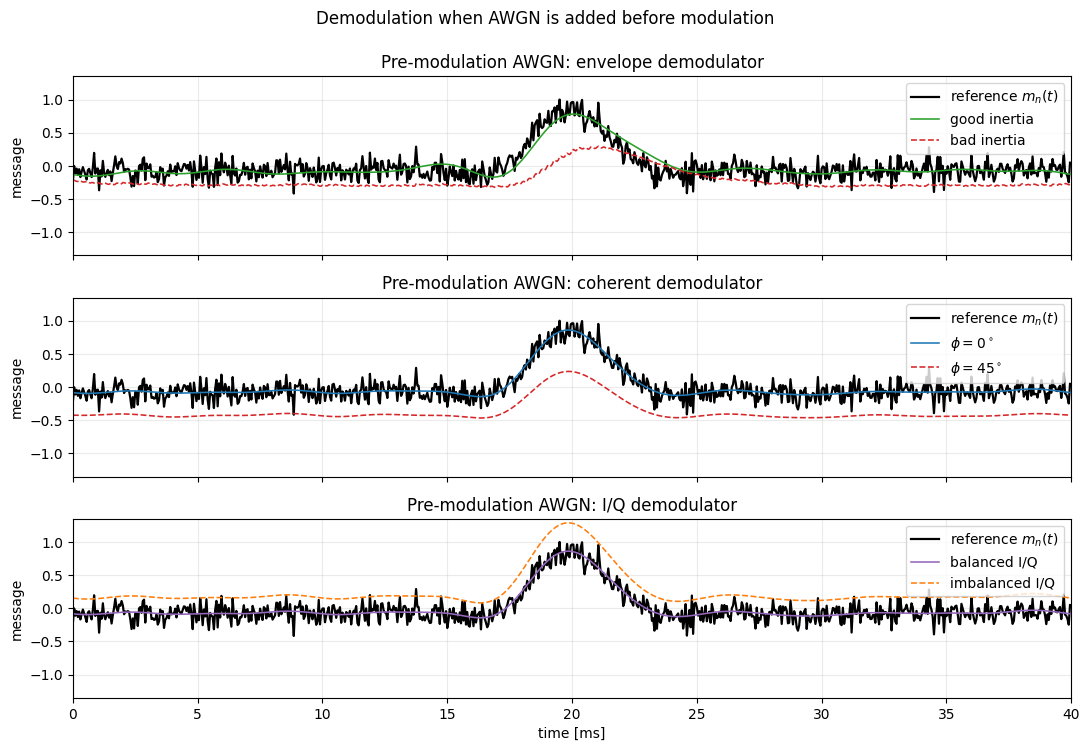

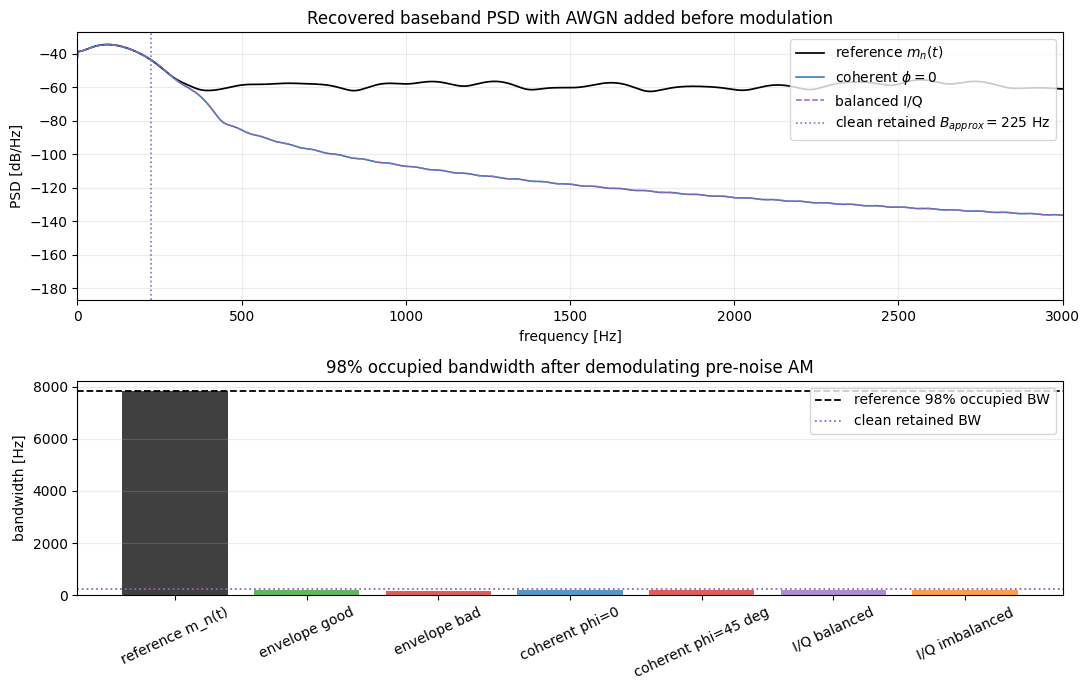

Clean retained bandwidth B_approx = 225.0 Hz
Pre-noise reference 98% occupied bandwidth = 7825.8 Hz
reference m_n(t): 98% occupied BW = 7825.8 Hz, retained-bin BW = 225.0 Hz
envelope good: 98% occupied BW = 207.2 Hz, retained-bin BW = 225.0 Hz
envelope bad: 98% occupied BW = 169.7 Hz, retained-bin BW = 225.0 Hz
coherent phi=0: 98% occupied BW = 189.4 Hz, retained-bin BW = 225.0 Hz
coherent phi=45 deg: 98% occupied BW = 188.9 Hz, retained-bin BW = 225.0 Hz
I/Q balanced: 98% occupied BW = 189.4 Hz, retained-bin BW = 225.0 Hz
I/Q imbalanced: 98% occupied BW = 189.5 Hz, retained-bin BW = 225.0 Hz


In [27]:
# Demodulate the signal produced by adding AWGN before modulation.
pre_noise_reference = m_noisy
pre_noise_signal = s_pre_noisy

# Envelope detector: good and bad inertia on the pre-noise AM signal.
pre_env_good = envelope_detector(pre_noise_signal, fs, attack_tau=good_attack_tau, release_tau=good_release_tau)
pre_env_bad = envelope_detector(pre_noise_signal, fs, attack_tau=bad_attack_tau, release_tau=bad_release_tau)
pre_env_good = lowpass_fft(pre_env_good, fs, cutoff_hz=lp_cutoff)
pre_m_env_good = recover_message_from_envelope(pre_env_good, Ac, mu_pre_noise)
pre_m_env_bad = recover_message_from_envelope(pre_env_bad, Ac, mu_pre_noise)

# Coherent demodulator: phi=0 and nonzero phase.
pre_m_coherent_good = coherent_demodulate(pre_noise_signal, fs, fc, Ac, mu_pre_noise, phi_good, lp_cutoff)
pre_m_coherent_bad = coherent_demodulate(pre_noise_signal, fs, fc, Ac, mu_pre_noise, phi_bad, lp_cutoff)

# I/Q demodulator: balanced and imbalanced.
pre_m_iq_balanced = iq_demodulate(pre_noise_signal, fs, fc, Ac, mu_pre_noise, lp_cutoff)
pre_m_iq_imbalanced = iq_demodulate(
    pre_noise_signal,
    fs,
    fc,
    Ac,
    mu_pre_noise,
    lp_cutoff,
    i_gain=i_gain_bad,
    q_gain=q_gain_bad,
    phase_error=quadrature_phase_error,
)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
time_ms = t * 1_000

axes[0].plot(time_ms, pre_noise_reference, color="black", linewidth=1.6, label="reference $m_n(t)$")
axes[0].plot(time_ms, pre_m_env_good, color="tab:green", linewidth=1.15, label="good inertia")
axes[0].plot(time_ms, pre_m_env_bad, color="tab:red", linewidth=1.15, linestyle="--", label="bad inertia")
axes[0].set_title("Pre-modulation AWGN: envelope demodulator")
axes[0].set_ylabel("message")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

axes[1].plot(time_ms, pre_noise_reference, color="black", linewidth=1.6, label="reference $m_n(t)$")
axes[1].plot(time_ms, pre_m_coherent_good, color="tab:blue", linewidth=1.15, label=rf"$\phi={np.rad2deg(phi_good):.0f}^\circ$")
axes[1].plot(time_ms, pre_m_coherent_bad, color="tab:red", linewidth=1.15, linestyle="--", label=rf"$\phi={np.rad2deg(phi_bad):.0f}^\circ$")
axes[1].set_title("Pre-modulation AWGN: coherent demodulator")
axes[1].set_ylabel("message")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

axes[2].plot(time_ms, pre_noise_reference, color="black", linewidth=1.6, label="reference $m_n(t)$")
axes[2].plot(time_ms, pre_m_iq_balanced, color="tab:purple", linewidth=1.15, label="balanced I/Q")
axes[2].plot(time_ms, pre_m_iq_imbalanced, color="tab:orange", linewidth=1.15, linestyle="--", label="imbalanced I/Q")
axes[2].set_title("Pre-modulation AWGN: I/Q demodulator")
axes[2].set_xlabel("time [ms]")
axes[2].set_ylabel("message")
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right")

for ax in axes:
    ax.set_ylim(-1.35, 1.35)
axes[-1].set_xlim(0, T * 1_000)
fig.suptitle("Demodulation when AWGN is added before modulation", y=0.995)
fig.tight_layout()
plt.show()

# Bandwidth comparison for the pre-noise demodulated signals.
def occupied_bandwidth_from_psd(signal, fs, energy_fraction=0.98, n_fft=131_072):
    centered = np.asarray(signal, dtype=float) - np.mean(signal)
    window = np.hanning(centered.size)
    coeffs = np.fft.rfft(centered * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1 / fs)
    power = np.abs(coeffs) ** 2
    if power.sum() <= 0:
        return 0.0, freqs, power
    cumulative = np.cumsum(power) / np.sum(power)
    idx = int(np.searchsorted(cumulative, energy_fraction, side="left"))
    return freqs[min(idx, freqs.size - 1)], freqs, power

pre_recovered_signals = {
    "reference m_n(t)": pre_noise_reference,
    "envelope good": pre_m_env_good,
    "envelope bad": pre_m_env_bad,
    "coherent phi=0": pre_m_coherent_good,
    "coherent phi=45 deg": pre_m_coherent_bad,
    "I/Q balanced": pre_m_iq_balanced,
    "I/Q imbalanced": pre_m_iq_imbalanced,
}

pre_bandwidth_results = {}
for label, signal in pre_recovered_signals.items():
    bw_98, freqs_bw, power_bw = occupied_bandwidth_from_psd(signal, fs, energy_fraction=0.98)
    bin_bw, highest_bin, amplitudes = measured_bandwidth_from_bins(signal, bins, T)
    pre_bandwidth_results[label] = {
        "occupied_98": bw_98,
        "retained_bin_bw": bin_bw,
        "highest_bin": highest_bin,
        "amplitudes": amplitudes,
    }

fig, axes = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [1.25, 1.0]})

freqs_ref, psd_ref = welch_psd(pre_noise_reference, fs, segment_length=256, overlap=0.75, n_fft=131_072)
freqs_good, psd_good = welch_psd(pre_m_coherent_good, fs, segment_length=256, overlap=0.75, n_fft=131_072)
freqs_iq, psd_iq = welch_psd(pre_m_iq_balanced, fs, segment_length=256, overlap=0.75, n_fft=131_072)

axes[0].plot(freqs_ref, db10(psd_ref), color="black", linewidth=1.25, label="reference $m_n(t)$")
axes[0].plot(freqs_good, db10(psd_good), color="tab:blue", linewidth=1.1, label=r"coherent $\phi=0$")
axes[0].plot(freqs_iq, db10(psd_iq), color="tab:purple", linewidth=1.1, linestyle="--", label="balanced I/Q")
axes[0].axvline(approx_bandwidth, color="tab:purple", linestyle=":", linewidth=1.2, label=rf"clean retained $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[0].set_title("Recovered baseband PSD with AWGN added before modulation")
axes[0].set_xlabel("frequency [Hz]")
axes[0].set_ylabel("PSD [dB/Hz]")
axes[0].set_xlim(0, frequency_axis_max)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

labels = list(pre_bandwidth_results.keys())
occupied_values = [pre_bandwidth_results[label]["occupied_98"] for label in labels]
colors = ["black", "tab:green", "tab:red", "tab:blue", "tab:red", "tab:purple", "tab:orange"]
axes[1].bar(labels, occupied_values, color=colors, alpha=0.75)
axes[1].axhline(pre_bandwidth_results["reference m_n(t)"]["occupied_98"], color="black", linestyle="--", linewidth=1.3, label="reference 98% occupied BW")
axes[1].axhline(approx_bandwidth, color="tab:purple", linestyle=":", linewidth=1.3, label="clean retained BW")
axes[1].set_title("98% occupied bandwidth after demodulating pre-noise AM")
axes[1].set_ylabel("bandwidth [Hz]")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

print(f"Clean retained bandwidth B_approx = {approx_bandwidth:.1f} Hz")
print(f"Pre-noise reference 98% occupied bandwidth = {pre_bandwidth_results['reference m_n(t)']['occupied_98']:.1f} Hz")
for label, result in pre_bandwidth_results.items():
    print(
        f"{label}: 98% occupied BW = {result['occupied_98']:.1f} Hz, "
        f"retained-bin BW = {result['retained_bin_bw']:.1f} Hz"
    )


## Over-Modulation With Bad Demodulation Settings

This final stress test combines two failure sources:

1. the modulation index is pushed to
$$
\mu=1.5,
$$
so the AM envelope $A_c[1+\mu m(t)]$ crosses zero when $m(t)<-1/\mu$;
2. the receiver settings are intentionally bad: envelope inertia is poorly chosen, coherent demodulation uses $\phi\ne0$, and I/Q demodulation has gain and phase imbalance.

For $\mu>1$, ordinary envelope detection is not theoretically valid when the message has enough negative excursion for the signed envelope to become negative. To make that failure explicit, this section uses a bipolar-normalized version of the same retained-bin message for the stress test. The carrier undergoes local phase reversals, so the magnitude envelope no longer equals $A_c[1+\mu m(t)]$. Coherent and I/Q methods can still expose the baseband structure more directly, but phase error and imbalance distort the recovered amplitude and bias.

The final figure uses a two-factor layout instead of a single worst-case trace. Each row fixes the pre-modulation input SNR, and each column fixes the demodulation method. The noisy baseband message is plotted in every panel because it is the signal that actually entered the modulator; the recovered curves are still expected to be low-pass receiver outputs, not exact reconstructions of all broadband noise.


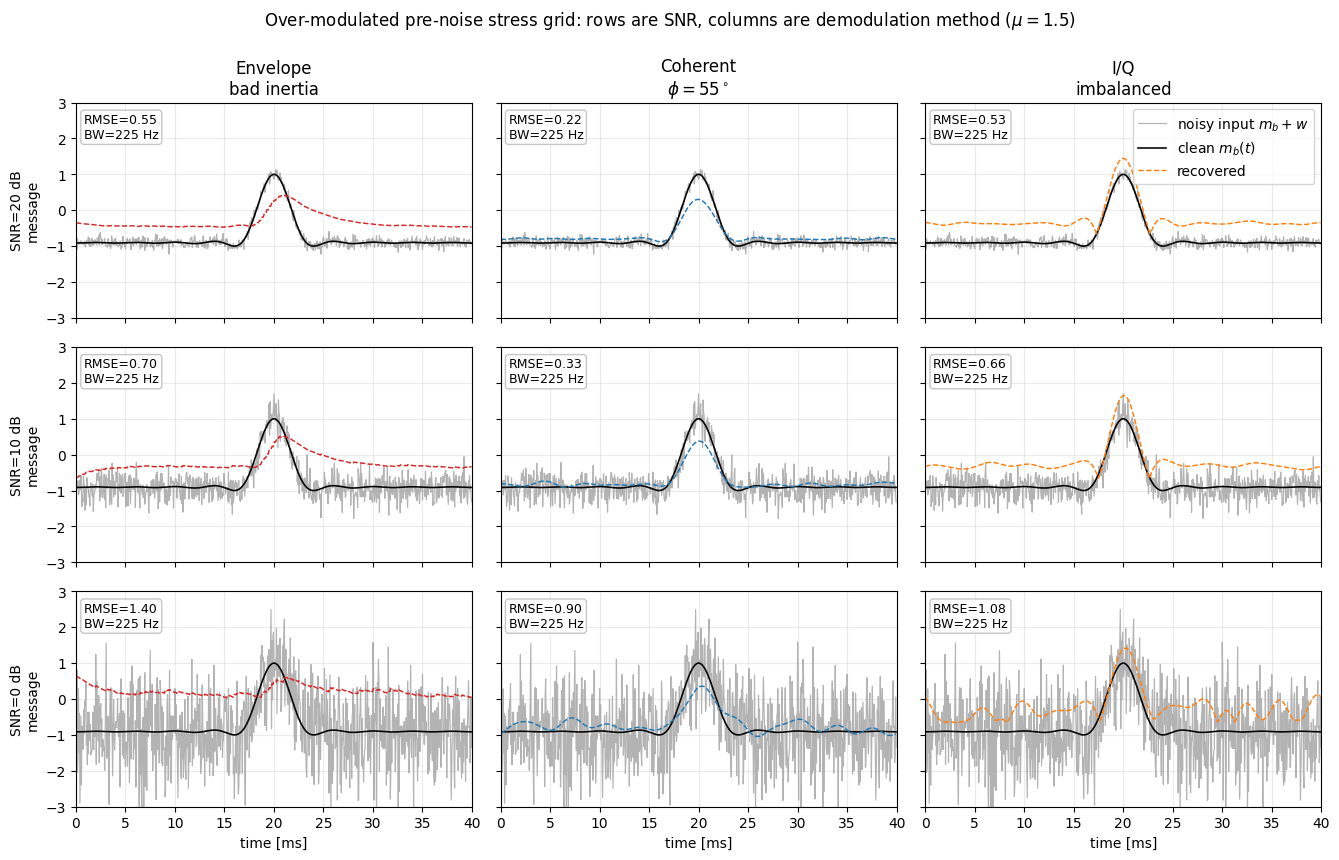

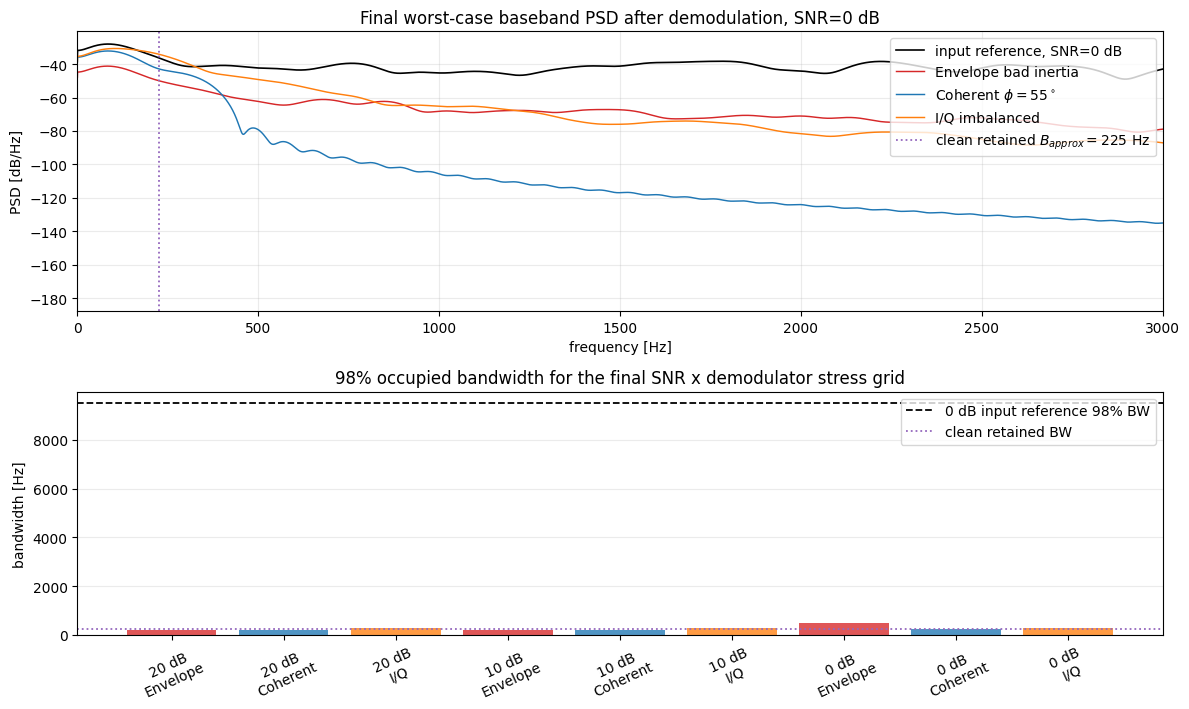

Failure-case modulation index mu = 1.5
Fraction of samples with signed envelope < 0 = 0.864
Expected retained bandwidth B_approx = 225.0 Hz
bipolar reference: bandwidth = 225.0 Hz, highest bin = 9, RMSE vs clean reference = 0.000
bad envelope, mu=1.5: bandwidth = 225.0 Hz, highest bin = 9, RMSE vs clean reference = 0.528
bad coherent, mu=1.5: bandwidth = 225.0 Hz, highest bin = 9, RMSE vs clean reference = 0.198
bad I/Q, mu=1.5: bandwidth = 225.0 Hz, highest bin = 9, RMSE vs clean reference = 0.525
SNR=20 dB, Envelope bad inertia: variance = 0.0076, bandwidth = 225.0 Hz, highest bin = 9, RMSE vs noisy input = 0.548, RMSE vs clean reference = 0.541
SNR=20 dB, Coherent $\phi=55^\circ$: variance = 0.0076, bandwidth = 225.0 Hz, highest bin = 9, RMSE vs noisy input = 0.217, RMSE vs clean reference = 0.197
SNR=20 dB, I/Q imbalanced: variance = 0.0076, bandwidth = 225.0 Hz, highest bin = 9, RMSE vs noisy input = 0.525, RMSE vs clean reference = 0.520
SNR=10 dB, Envelope bad inertia: variance 

In [28]:
mu_failure = 1.5
# Use the same retained-bin waveform, but bipolar-normalize it for this stress
# test so mu > 1 genuinely produces envelope sign reversals.
m_failure_ref = 2 * (m - np.min(m)) / (np.max(m) - np.min(m)) - 1
s_failure = Ac * (1 + mu_failure * m_failure_ref) * carrier
signed_envelope_failure = Ac * (1 + mu_failure * m_failure_ref)
overmodulated_mask = signed_envelope_failure < 0

# Bad demodulator settings reused or strengthened for the failure case.
failure_phi = np.deg2rad(55)
failure_i_gain = 1.25
failure_q_gain = 0.50
failure_iq_phase_error = np.deg2rad(28)
failure_attack_tau = bad_attack_tau
failure_release_tau = bad_release_tau

failure_env = envelope_detector(s_failure, fs, attack_tau=failure_attack_tau, release_tau=failure_release_tau)
failure_m_env = recover_message_from_envelope(failure_env, Ac, mu_failure)
failure_m_coherent = coherent_demodulate(s_failure, fs, fc, Ac, mu_failure, failure_phi, lp_cutoff)
failure_m_iq = iq_demodulate(
    s_failure,
    fs,
    fc,
    Ac,
    mu_failure,
    lp_cutoff,
    i_gain=failure_i_gain,
    q_gain=failure_q_gain,
    phase_error=failure_iq_phase_error,
)

time_ms = t * 1_000

failure_recovered = {
    "bipolar reference": m_failure_ref,
    "bad envelope, mu=1.5": failure_m_env,
    "bad coherent, mu=1.5": failure_m_coherent,
    "bad I/Q, mu=1.5": failure_m_iq,
}

failure_bandwidths = {}
for label, signal in failure_recovered.items():
    measured_bw, highest_bin, amplitudes = measured_bandwidth_from_bins(signal, bins, T)
    rmse = np.sqrt(np.mean((signal - m_failure_ref) ** 2))
    failure_bandwidths[label] = {
        "bandwidth": measured_bw,
        "highest_bin": highest_bin,
        "amplitudes": amplitudes,
        "rmse": rmse,
    }

# A controlled SNR x demodulator grid is more informative than a single worst
# trace: rows isolate the input SNR and columns isolate the receiver impairment.
def failure_envelope_demod(signal):
    envelope = envelope_detector(signal, fs, attack_tau=failure_attack_tau, release_tau=failure_release_tau)
    return recover_message_from_envelope(envelope, Ac, mu_failure)


def failure_coherent_demod(signal):
    return coherent_demodulate(signal, fs, fc, Ac, mu_failure, failure_phi, lp_cutoff)


def failure_iq_demod(signal):
    return iq_demodulate(
        signal,
        fs,
        fc,
        Ac,
        mu_failure,
        lp_cutoff,
        i_gain=failure_i_gain,
        q_gain=failure_q_gain,
        phase_error=failure_iq_phase_error,
    )


failure_demod_methods = [
    ("Envelope\nbad inertia", failure_envelope_demod, "tab:red"),
    (f"Coherent\n$\\phi={np.rad2deg(failure_phi):.0f}^\\circ$", failure_coherent_demod, "tab:blue"),
    ("I/Q\nimbalanced", failure_iq_demod, "tab:orange"),
]

failure_snr_db_values = [20, 10, 0]
failure_grid_rng = np.random.default_rng(2026)
reference_power = np.mean(m_failure_ref**2)
failure_grid_results = {}

fig, axes = plt.subplots(
    len(failure_snr_db_values),
    len(failure_demod_methods),
    figsize=(13.5, 8.6),
    sharex=True,
    sharey=True,
)

for row, snr_db in enumerate(failure_snr_db_values):
    noise_variance = reference_power / (10 ** (snr_db / 10))
    noisy_reference = m_failure_ref + failure_grid_rng.normal(0.0, np.sqrt(noise_variance), size=t.size)
    s_failure_noisy_input = Ac * (1 + mu_failure * noisy_reference) * carrier
    row_results = {}

    for col, (method_label, demodulator, color) in enumerate(failure_demod_methods):
        ax = axes[row, col]
        recovered = demodulator(s_failure_noisy_input)
        measured_bw, highest_bin, amplitudes = measured_bandwidth_from_bins(recovered, bins, T)
        rmse_to_noisy = np.sqrt(np.mean((recovered - noisy_reference) ** 2))
        rmse_to_clean = np.sqrt(np.mean((recovered - m_failure_ref) ** 2))
        row_results[method_label] = {
            "noise_variance": noise_variance,
            "snr_db": snr_db,
            "bandwidth": measured_bw,
            "highest_bin": highest_bin,
            "amplitudes": amplitudes,
            "rmse_to_noisy": rmse_to_noisy,
            "rmse_to_clean": rmse_to_clean,
            "recovered": recovered,
            "noisy_reference": noisy_reference,
        }

        ax.plot(time_ms, noisy_reference, color="0.62", linewidth=0.85, alpha=0.78, label="noisy input $m_b+w$")
        ax.plot(time_ms, m_failure_ref, color="black", linewidth=1.15, label="clean $m_b(t)$")
        ax.plot(time_ms, recovered, color=color, linewidth=1.05, linestyle="--", label="recovered")
        ax.text(
            0.02,
            0.95,
            f"RMSE={rmse_to_noisy:.2f}\nBW={measured_bw:.0f} Hz",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.75", "alpha": 0.88},
        )
        ax.grid(True, alpha=0.25)
        ax.set_ylim(-3.0, 3.0)
        if row == 0:
            ax.set_title(method_label)
        if col == 0:
            ax.set_ylabel(f"SNR={snr_db} dB\nmessage")
        if row == len(failure_snr_db_values) - 1:
            ax.set_xlabel("time [ms]")

    failure_grid_results[snr_db] = row_results

axes[0, -1].legend(loc="upper right")
axes[-1, -1].set_xlim(0, T * 1_000)
fig.suptitle(rf"Over-modulated pre-noise stress grid: rows are SNR, columns are demodulation method ($\mu={mu_failure:g}$)", y=0.995)
fig.tight_layout()
plt.show()

# Frequency-domain summary for the final stress grid. The PSD overlay uses the
# lowest-SNR row, while the bar chart compares 98% occupied bandwidth across all
# SNR/method combinations.
worst_snr_db = failure_snr_db_values[-1]
worst_row_results = failure_grid_results[worst_snr_db]
method_colors = {label: color for label, _, color in failure_demod_methods}

fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), gridspec_kw={"height_ratios": [1.15, 1.0]})

worst_reference = next(iter(worst_row_results.values()))["noisy_reference"]
freqs_ref, psd_ref = welch_psd(worst_reference, fs, segment_length=256, overlap=0.75, n_fft=131_072)
axes[0].plot(freqs_ref, db10(psd_ref), color="black", linewidth=1.2, label=rf"input reference, SNR={worst_snr_db} dB")

final_psd_bandwidths = {}
reference_bw_98, _, _ = occupied_bandwidth_from_psd(worst_reference, fs, energy_fraction=0.98)
for method_label, result in worst_row_results.items():
    freqs_rec, psd_rec = welch_psd(result["recovered"], fs, segment_length=256, overlap=0.75, n_fft=131_072)
    display_label = method_label.replace("\n", " ")
    axes[0].plot(freqs_rec, db10(psd_rec), color=method_colors[method_label], linewidth=1.05, label=display_label)

axes[0].axvline(approx_bandwidth, color="tab:purple", linestyle=":", linewidth=1.3, label=rf"clean retained $B_{{approx}}={approx_bandwidth:g}$ Hz")
axes[0].set_title(rf"Final worst-case baseband PSD after demodulation, SNR={worst_snr_db} dB")
axes[0].set_xlabel("frequency [Hz]")
axes[0].set_ylabel("PSD [dB/Hz]")
axes[0].set_xlim(0, frequency_axis_max)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

bar_labels = []
bar_values = []
bar_colors = []
for snr_db, row_results in failure_grid_results.items():
    for method_label, result in row_results.items():
        bw_98, _, _ = occupied_bandwidth_from_psd(result["recovered"], fs, energy_fraction=0.98)
        result["occupied_98"] = bw_98
        short_method = method_label.split("\n", 1)[0]
        bar_labels.append(f"{snr_db} dB\n{short_method}")
        bar_values.append(bw_98)
        bar_colors.append(method_colors[method_label])

axes[1].bar(bar_labels, bar_values, color=bar_colors, alpha=0.78)
axes[1].axhline(reference_bw_98, color="black", linestyle="--", linewidth=1.3, label=rf"{worst_snr_db} dB input reference 98% BW")
axes[1].axhline(approx_bandwidth, color="tab:purple", linestyle=":", linewidth=1.3, label="clean retained BW")
axes[1].set_title("98% occupied bandwidth for the final SNR x demodulator stress grid")
axes[1].set_ylabel("bandwidth [Hz]")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

print(f"Failure-case modulation index mu = {mu_failure}")
print(f"Fraction of samples with signed envelope < 0 = {np.mean(overmodulated_mask):.3f}")
print(f"Expected retained bandwidth B_approx = {approx_bandwidth:.1f} Hz")
for label, result in failure_bandwidths.items():
    highest = result["highest_bin"] if result["highest_bin"] is not None else "none"
    print(
        f"{label}: bandwidth = {result['bandwidth']:.1f} Hz, "
        f"highest bin = {highest}, RMSE vs clean reference = {result['rmse']:.3f}"
    )
for snr_db, row_results in failure_grid_results.items():
    for label, result in row_results.items():
        highest = result["highest_bin"] if result["highest_bin"] is not None else "none"
        one_line_label = label.replace("\n", " ")
        print(
            f"SNR={snr_db:>2} dB, {one_line_label}: variance = {result['noise_variance']:.4f}, "
            f"bandwidth = {result['bandwidth']:.1f} Hz, highest bin = {highest}, "
            f"RMSE vs noisy input = {result['rmse_to_noisy']:.3f}, "
            f"RMSE vs clean reference = {result['rmse_to_clean']:.3f}"
        )
